<a href="https://colab.research.google.com/github/roughhawkbit/digi-inno-road-prod/blob/main/analysis/1_2-firm-size-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook analyses the various variables associated with firm size.

**Recommended runtime:** CPU

# Setup

In [1]:
import os
import sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    repo_path = '/content/drive/MyDrive/digi-inno-road-prod'
    if os.path.isdir(repo_path):
      cwd = os.getcwd()
      os.chdir(repo_path)
      !git pull
      os.chdir(cwd)
    else:
      !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git /content/drive/MyDrive/digi-inno-road-prod
      print('Repository cloned into your Google Drive. It is strongly recommended that you copy the credentials.json, sheet.json, and token.json files into the secrets folder before proceeding.')
    sys.path.insert(0, repo_path)
    IN_COLAB = True
except ImportError:
    repo_path = os.path.abspath(os.path.join('../src'))
    IN_COLAB = False

if not repo_path in sys.path:
    sys.path.insert(0, repo_path)

Mounted at /content/drive
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 724 bytes | 0 bytes/s, done.
From https://github.com/roughhawkbit/digi-inno-road-prod
   ac3392d..27f7d8c  main       -> origin/main
Updating ac3392d..27f7d8c
Fast-forward
 analysis/Template.ipynb | 66 +++++++++++++++++++++++++++++--------------------
 1 file changed, 39 insertions(+), 27 deletions(-)


In [2]:
if IN_COLAB:
  output_path = os.path.join(repo_path, 'analysis', 'outputs')
else:
  output_path = os.path.join('.', 'outputs')
output_path = os.path.abspath(output_path)

# Import packages & data

Conda packages

In [131]:
import matplotlib
import numpy
import pandas

Project sourcecode packages

In [4]:
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.wrangling.msyh_data_sharing import wrangle_roadmaps, wrangle_grants

Data

In [22]:
data = get_sheet_dfs()

INCLUDE_NO_GRANTS_FIRMS = True
if INCLUDE_NO_GRANTS_FIRMS:
  roadmaps_df = pandas.concat([data['Roadmaps'], data['RoadmapsWithoutGrants']]).reset_index(drop=True)
else:
  roadmaps_df = data['Roadmaps']
roadmaps_df = wrangle_roadmaps(roadmaps_df)

grants_df = wrangle_grants(data['Grants'])

/content/drive/MyDrive/digi-inno-road-prod/innoprod/wrangling/wrangling_tools.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series.loc[mask] = new_value


# Analysis

## Analysis setup

In [45]:
org_size_col = 'Org Size by Number of FTE (calc)'
num_fte_col = 'Number of FTE Employees (calc)'
num_ft_col = 'Number of FT employees'
num_pt_col = 'Number of PT employees'
turnover_col = 'Turnover'
size_cols = [org_size_col, num_fte_col, num_ft_col, num_pt_col, turnover_col]
roadmaps_df[size_cols]

,Org Size by Number of FTE (calc),Number of FTE Employees (calc),Number of FT employees,Number of PT employees,Turnover
0,NaN,<NA>,<NA>,<NA>,NaN
1,Medium - 50-249,0.0,<NA>,<NA>,9930189.0
2,Medium - 50-249,0.0,<NA>,<NA>,NaN
3,Medium - 50-249,0.0,<NA>,<NA>,9200095.0
4,Medium - 50-249,0.0,<NA>,<NA>,7000000.0
...,...,...,...,...,...
816,Micro - 1-9,3.0,3,<NA>,610000.0
817,Micro - 1-9,3.0,3,<NA>,200000.0
818,NaN,0.0,<NA>,<NA>,102000.0
819,NaN,0.0,<NA>,<NA>,NaN


## Org Size alone

We have "Org Size" categorical data for this many firms:

In [30]:
int(roadmaps_df[org_size_col].notna().sum())

599

They are distributed as such:

In [32]:
roadmaps_df[roadmaps_df[org_size_col].notna()][org_size_col].value_counts()

,count
Org Size by Number of FTE (calc),
Small - 10-49,305
Micro - 1-9,193
Medium - 50-249,101


## Numbers of FTE, FT, and PT

We have a valid "Number of FTE" for this many firms:

In [35]:
valid_fte_mask = roadmaps_df[num_fte_col].notna()
int(valid_fte_mask.sum())

718

However, many of these values are zeros. Excluding the zeros leaves this many firms:

In [36]:
valid_fte_mask = (roadmaps_df[num_fte_col] > 0.0).fillna(False)
int(valid_fte_mask.sum())

406

The numbers of FT or PT employees appear to be free of the spurious zeros afflicting the "Number of FTE employees" column.

In [43]:
int((roadmaps_df[num_ft_col] == 0.0).fillna(False).sum())

0

In [44]:
int((roadmaps_df[num_pt_col] == 0.0).fillna(False).sum())

1

Looking at the missing or zero `Number of FTE` values, we find that this matches up perfectly with missing values in **both** the `Number of FT employees` and the `Number of PT employees` columns

In [58]:
invalid_fte_mask = (roadmaps_df[num_fte_col] == 0.0).fillna(True)
bool((roadmaps_df[invalid_fte_mask][num_ft_col].isna() & roadmaps_df[invalid_fte_mask][num_pt_col].isna()).all())

True

Wherever
1. the `Number of FTE` is given, and
2. the `Number of FT employees` is given, but
3. the `Number of PT employees` is missing or zero,

the `Number of FTE` and the `Number of FT employees` match.

In [60]:
roadmaps_df[valid_fte_mask & (roadmaps_df[num_pt_col] == 0.0).fillna(True)][size_cols]

,Org Size by Number of FTE (calc),Number of FTE Employees (calc),Number of FT employees,Number of PT employees,Turnover
20,Micro - 1-9,1.0,<NA>,<NA>,NaN
21,Micro - 1-9,2.0,2,<NA>,60000.0
22,Micro - 1-9,3.0,<NA>,<NA>,375000.0
23,Micro - 1-9,5.0,<NA>,<NA>,NaN
24,Micro - 1-9,5.0,5,<NA>,3900000.0
...,...,...,...,...,...
814,Micro - 1-9,4.0,4,<NA>,186568.0
815,Small - 10-49,23.0,23,<NA>,NaN
816,Micro - 1-9,3.0,3,<NA>,610000.0
817,Micro - 1-9,3.0,3,<NA>,200000.0


In [65]:
mask = valid_fte_mask & (roadmaps_df[num_pt_col] == 0.0).fillna(True) & roadmaps_df[num_ft_col].notna()
bool((roadmaps_df[mask][num_fte_col] == roadmaps_df[mask][num_ft_col]).all())

True

In the small number of cases where the `Number of PT employees` is given, each PT employee appears to be assumed to be equivalent to half of one FT employee when calculating the `Number of FTE employees`

In [68]:
mask = (roadmaps_df[num_pt_col] > 0.0).fillna(False)
roadmaps_df[mask][size_cols]

,Org Size by Number of FTE (calc),Number of FTE Employees (calc),Number of FT employees,Number of PT employees,Turnover
159,Micro - 1-9,1.0,<NA>,2,86000.0
479,Micro - 1-9,9.0,8,2,470000.0
809,Micro - 1-9,4.5,4,1,NaN


In [72]:
roadmaps_df[mask][num_fte_col] == (roadmaps_df[mask][num_ft_col].fillna(0.0) + 0.5*roadmaps_df[mask][num_pt_col])

,0
159,True
479,True
809,True


Overall, we conclude that `Number of FTE employees (calc)` is a fair summation of the `Number of FT employees` and the `Number of PT employees` columns.

## Org Size and Number of FTE employees

There are no firms for which the `Number of FTE employees` is given and above zero, but for which the `Org Size` category is missing.

In [84]:
bool((valid_fte_mask & roadmaps_df[org_size_col].isna()).any())

False

However, there are this many firms where the `Org Size` category is given but the `Number of FTE employees` is missing or zero:

In [92]:
int((invalid_fte_mask & roadmaps_df[org_size_col].notna()).sum())

193

If we look at the firms where both the `Org Size` category is given and the `Number of FTE employees` is given and greater than zero, we find that the categories do not always match up:

In [101]:
roadmaps_df[mask].groupby(org_size_col, observed=True)[num_fte_col].apply(lambda grp: {'Min': grp.min(), 'Max': grp.max(), 'Count': grp.count()})

Org Size by Number of FTE (calc)       
Micro - 1-9                       Min        1.0
                                  Max        9.0
                                  Count    134.0
Small - 10-49                     Min       10.0
                                  Max       70.0
                                  Count    196.0
Medium - 50-249                   Min       50.0
                                  Max      300.0
                                  Count     76.0
Name: Number of FTE Employees (calc), dtype: float64

This many firms labeled with an `Org Size` of `Small - 10-49` have more than 49:

In [113]:
len(roadmaps_df[mask & (roadmaps_df[org_size_col] == 'Small - 10-49') & (roadmaps_df[num_fte_col] > 49)])

1

And this many firms labeled with an `Org Size` of `Medium - 50-249` have more than 249:

In [114]:
len(roadmaps_df[mask & (roadmaps_df[org_size_col] == 'Medium - 50-249') & (roadmaps_df[num_fte_col] > 249)])

2

Out of hundreds of firms, so few categorisation errors is negligle, and so we conclude that the `Org Size` category is consistent with the `Number of FTE` columns. `Org Size` lacks precision but has greater coverage.

## Turnover alone

We have Turnover data for many of the firms. Any null values ("£-") were reassigned NaN value at data ingress and formatting.

In [115]:
roadmaps_df['Turnover'].notna().value_counts()

,count
Turnover,
True,465
False,356


No firms reported zero turnover.

In [117]:
bool((roadmaps_df['Turnover'] == 0.0).any())

False

There is one firm with a reported Turnover of £500 million, which is far greater than any other.

<Axes: >

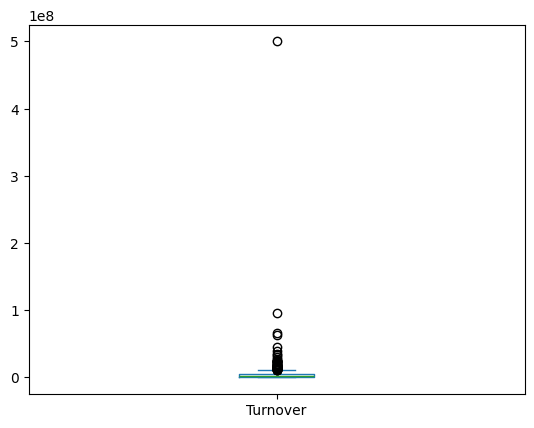

In [119]:
roadmaps_df['Turnover'].plot.box()

Inspecting this firm more closely:

In [120]:
roadmaps_df[roadmaps_df['Turnover'] == roadmaps_df['Turnover'].max()][size_cols]

,Org Size by Number of FTE (calc),Number of FTE Employees (calc),Number of FT employees,Number of PT employees,Turnover
147,Small - 10-49,0.0,<NA>,<NA>,500000000.0


Plotting the distribution of other firms reveals a rough power law:

<Axes: xlabel='Turnover (£)', ylabel='Number of firms'>

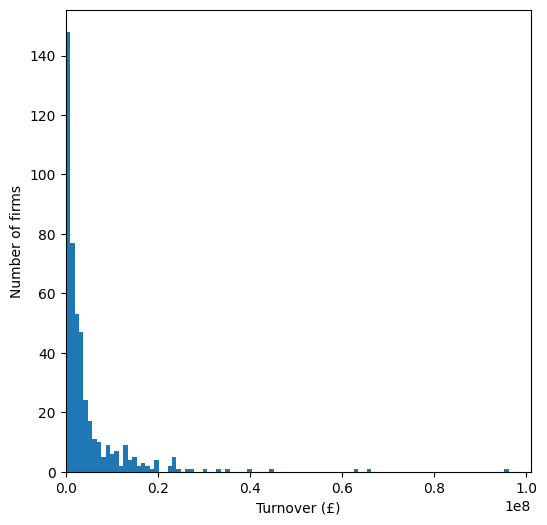

In [129]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.hist(roadmaps_df[roadmaps_df['Turnover'] < roadmaps_df['Turnover'].max()]['Turnover'], bins=100)
ax.set_xlim(left=0.0)
ax.set_xlabel('Turnover (£)')
ax.set_ylabel('Number of firms')
ax

Given the huge range in values, look at the log-Turnover (base 10 for readability) instead.

In [132]:
roadmaps_df['Log10 Turnover'] = numpy.log10(roadmaps_df['Turnover'])

<Axes: xlabel='Firm size', ylabel='Turnover'>

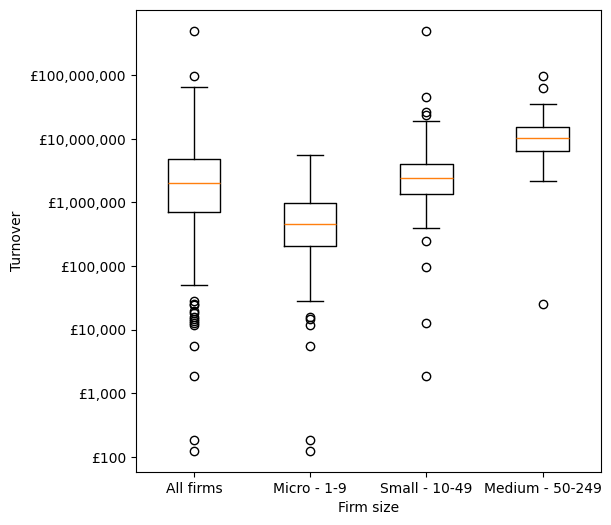

In [138]:
plot_data = [roadmaps_df['Log10 Turnover'].dropna().to_numpy()]

for org_s in ['Micro - 1-9', 'Small - 10-49', 'Medium - 50-249']:
  plot_data.append(roadmaps_df[roadmaps_df['Org Size by Number of FTE (calc)'] == org_s]['Log10 Turnover'].dropna().to_numpy())

fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.boxplot(plot_data)

ax.set_xlabel('Firm size')
ax.set_xticklabels(['All firms', 'Micro - 1-9', 'Small - 10-49', 'Medium - 50-249'])

ax.set_ylabel('Turnover')
ax.set_yticks(numpy.arange(2, 9, 1), labels=['£100', '£1,000', '£10,000', '£100,000', '£1,000,000', '£10,000,000', '£100,000,000'])

ax

## Number of FTE employees and Turnover